In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,  
})

In [3]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

embeddings = model.embeddings.word_embeddings.weight.detach()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3664.92it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


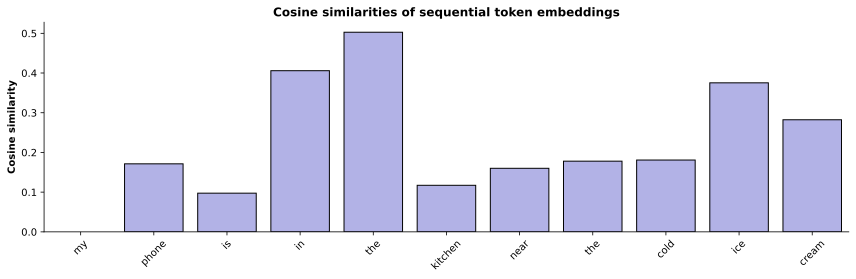

In [4]:
sentence = "my phone is in the kitchen near the cold ice cream"

tokens = tokenizer.encode(sentence)[1:-1]

cossim = np.full(len(tokens), np.nan)

for ti in range (1, len(tokens)):
    v1 = embeddings[tokens[ti], :]
    v2 = embeddings[tokens[ti-1], :]
    c = cosine_similarity(v1.reshape(1, -1), v2.reshape(1, -1))
    cossim[ti] = c.item()

plt.figure(figsize=(12,4))
plt.bar(np.arange(len(cossim)), cossim, facecolor=[.7, .7, .9], edgecolor='k')
plt.gca().set(xticks=range(len(tokens)),xticklabels=[tokenizer.decode(t) for t in tokens], xlim=[-0.5, len(tokens)-0.5], ylabel='Cosine similarity')
plt.gca().tick_params(axis='x', rotation=45)

plt.title('Cosine similarities of sequential token embeddings', fontweight='bold')

plt.tight_layout()
plt.savefig('ch3_proj9_part1.png')
plt.show()

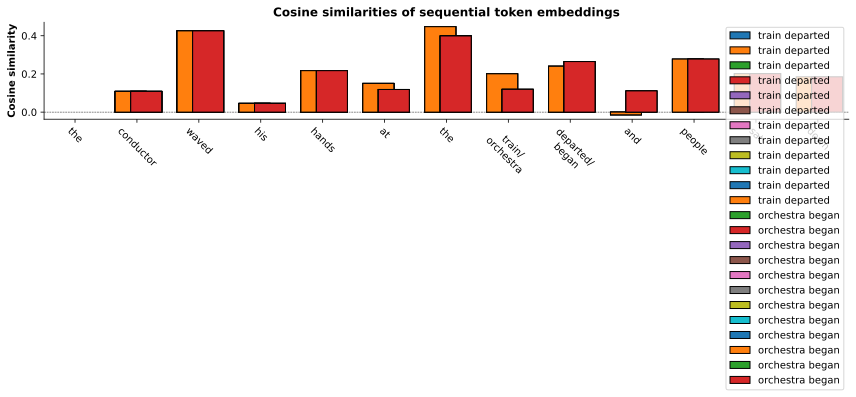

In [5]:
sentences = ['The conductor waved his hands as the train departed and people sat down',
             'The conductor waved his hands at the orchestra began and people sat down']

plt.figure(figsize=(12,4))

for i, sent in enumerate(sentences):
    tokens = tokenizer.encode(sent)[1:-1]
    cossim = np.full(len(tokens), np.nan)

    for ti in range(1, len(tokens)):
        v1 = embeddings[tokens[ti],:]
        v2 = embeddings[tokens[ti-1], :]
        c = cosine_similarity(v1.reshape(1, -1), v2.reshape(1, -1))
        cossim[ti] = c.item()

        plt.bar(np.arange(0,len(cossim))+i/4-.1,cossim,width=.5,edgecolor='k', label=tokenizer.decode(tokens[7:9]))

plt.axhline(0,linestyle='--',color='k',linewidth=.5,zorder=-3)
xticklabs = [tokenizer.decode(t) for t in tokens]
xticklabs[7] = f'train/\norchestra'
xticklabs[8] = 'departed/\nbegan'
plt.gca().set(xticks=range(len(tokens)),xticklabels=xticklabs, xlim=[-.5,len(tokens)-.5],ylabel='Cosine similarity')
plt.tick_params(axis='x',rotation=-45)
plt.legend()
plt.title('Cosine similarities of sequential token embeddings',fontweight='bold')

plt.tight_layout()
plt.savefig('ch3_proj9_part2.png')
plt.show()
